In [1]:
import Pkg
Pkg.activate("/home/matteo/Projects/diffusion_inference/")

  Activating project at `~/Projects/diffusion_inference`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

Precompiling DiffusionEvolution
  ✓ DiffusionEvolution
  1 dependency successfully precompiled in 4 seconds. 130 already precompiled.


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
@load "test1_save.jld2"

10-element Vector{Symbol}:
 :d
 :nsamples
 :T
 :J
 :θ
 :γ
 :x
 :results
 :t_sample
 :γ_grid

In [ ]:
d = 25
nsamples = 10_000
T = 1000

In [ ]:
M = randn(d,d) * 0.8/sqrt(d)
J = M * M'

In [ ]:
eigen(inv(J)).values

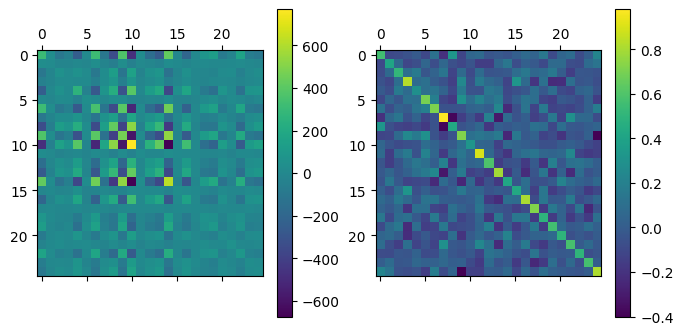

PyObject <matplotlib.colorbar.Colorbar object at 0x768055c36680>

In [54]:
fig, ax = subplots(1,2,4)

ax[1].matshow(inv(J)) |> colorbar
ax[2].matshow(J) |> colorbar

In [ ]:
θ0 = 5.0*rand(d)
θ1 = 5.0 * randn(d)
θ = θ0 .+ (θ1 .* randn(d))
θ |> norm

In [ ]:
θ[[1,2]]

In [ ]:
γ = 0.1

In [ ]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

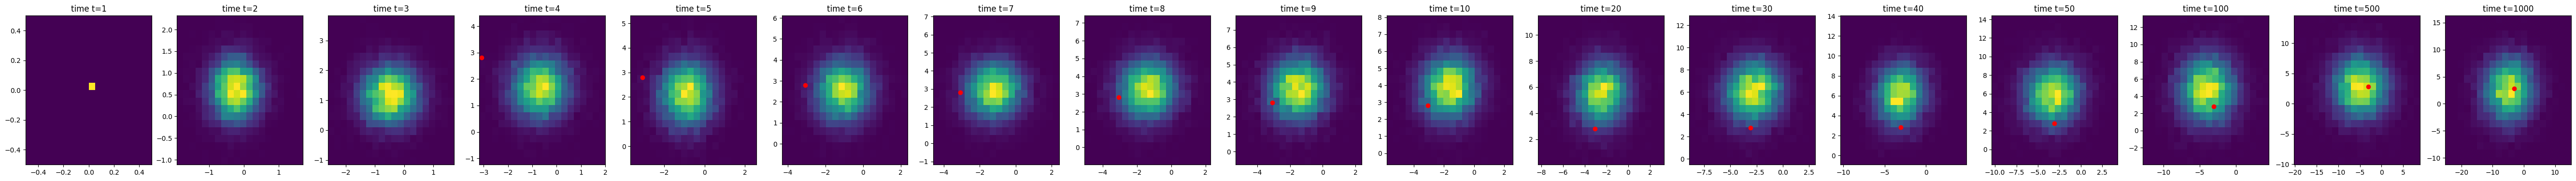

In [7]:
tpoints = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,100,500,1000]
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red")
    ax[t].set_title("time t=$(tpoints[t])")
end

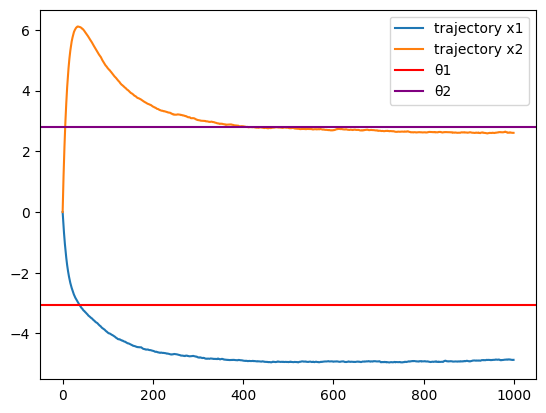

In [8]:
xt1 = vec(mean(x[1,:,:], dims=1))
xt2 = vec(mean(x[2,:,:], dims=1))
plot(xt1, label="trajectory x1")
plot(xt2, label="trajectory x2")
axhline(θ[1], color="red", label="θ1")
axhline(θ[2], color="purple", label="θ2")
legend();

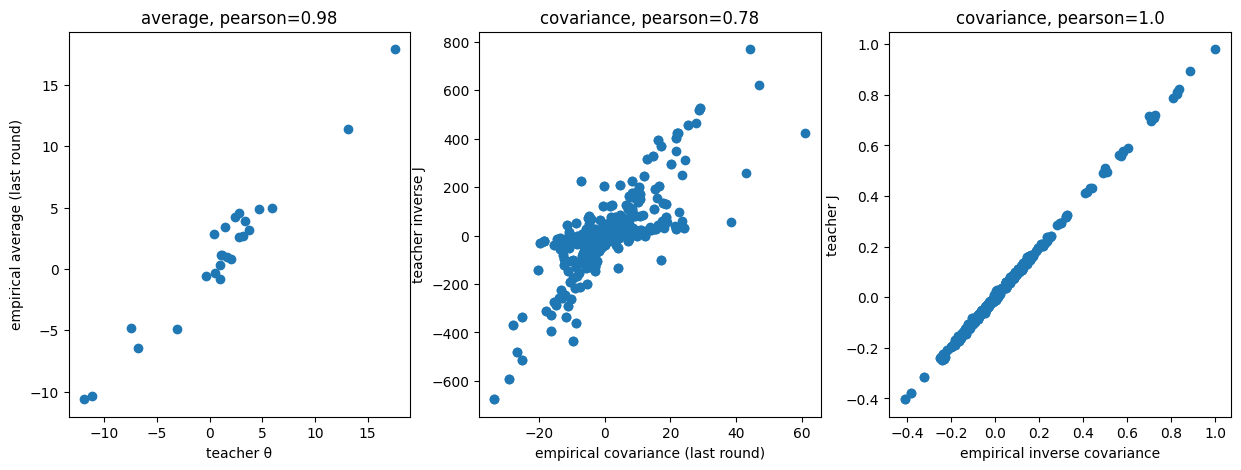

PyObject Text(0.5, 1.0, 'covariance, pearson=1.0')

In [9]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples
#Σ_eq ./= sqrt.(diag(Σ_eq)) * sqrt.(diag(Σ_eq))'

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [10]:
t_sample=[1, 2,3,4,5,10]

6-element Vector{Int64}:
  1
  2
  3
  4
  5
 10

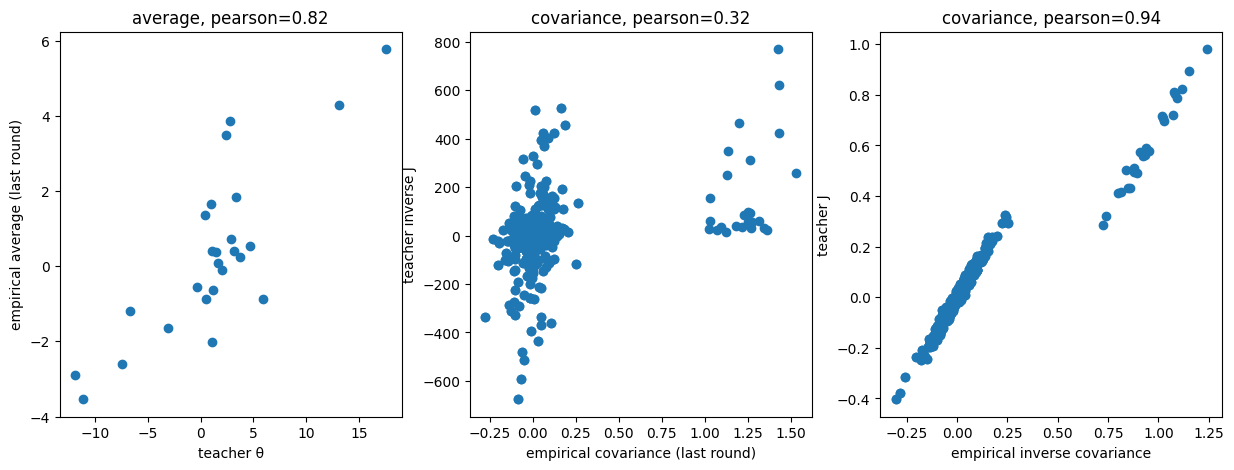

PyObject Text(0.5, 1.0, 'covariance, pearson=0.94')

In [11]:
fig, ax = subplots(1,3,5)
μ_last = mean(x[:,:,t_sample[end]], dims=2)
Σ_last = ((x[:,:,t_sample[end]] .- μ_last)*(x[:,:,t_sample[end]] .- μ_last)')./nsamples
#Σ_last ./= sqrt.(diag(Σ_last)) * sqrt.(diag(Σ_last))'

ax[1].scatter(θ, μ_last)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_last))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_last), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_last), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_last)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_last)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

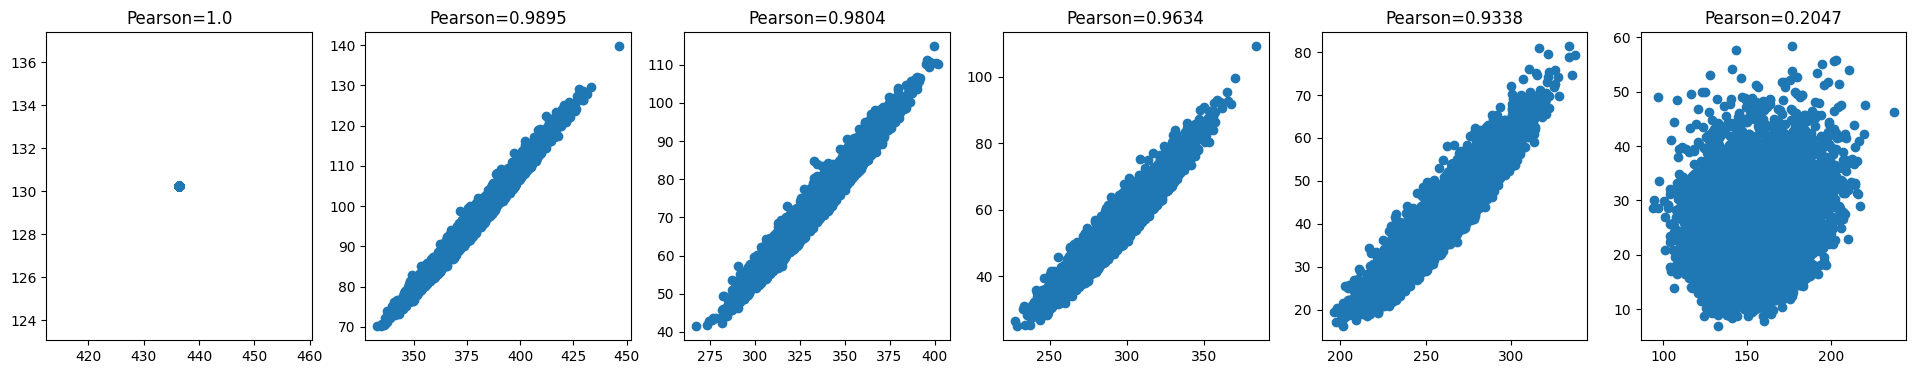

In [52]:
fig, ax = subplots(1, length(t_sample), 4)
for t in eachindex(t_sample)
    teacher_ene = compute_energy(x[:,:, t_sample[t]], J, θ)
    empirical_ene = compute_energy(x[:,:, t_sample[t]], inv(Σ_last), vec(μ_last));
    ax[t].scatter(teacher_ene, empirical_ene)
    rho = cor(teacher_ene, empirical_ene)
    ax[t].set_title("Pearson=$(round(rho, digits=4))")
end

In [25]:
counts = ones(nsamples, length(t_sample)) ./ nsamples
time = [1,2,3,4,5,10]
data = collect_data(zeros(d), x[:,:,t_sample], counts, time);

In [ ]:
λ = 0.0
prior = 0.01
ftol_rel = 1e-9

In [ ]:
results = learn_gamma_nlopt(data, initialize=length(t_sample), λ=λ, prior=prior, ftol_rel=ftol_rel, rescale=true, epsilon=0.0)

In [ ]:
results.minx[end]

In [26]:
J_inferred = de.compute_J(results.minx, data.d);
θ_inferred = de.compute_theta(results.minx, data.d);

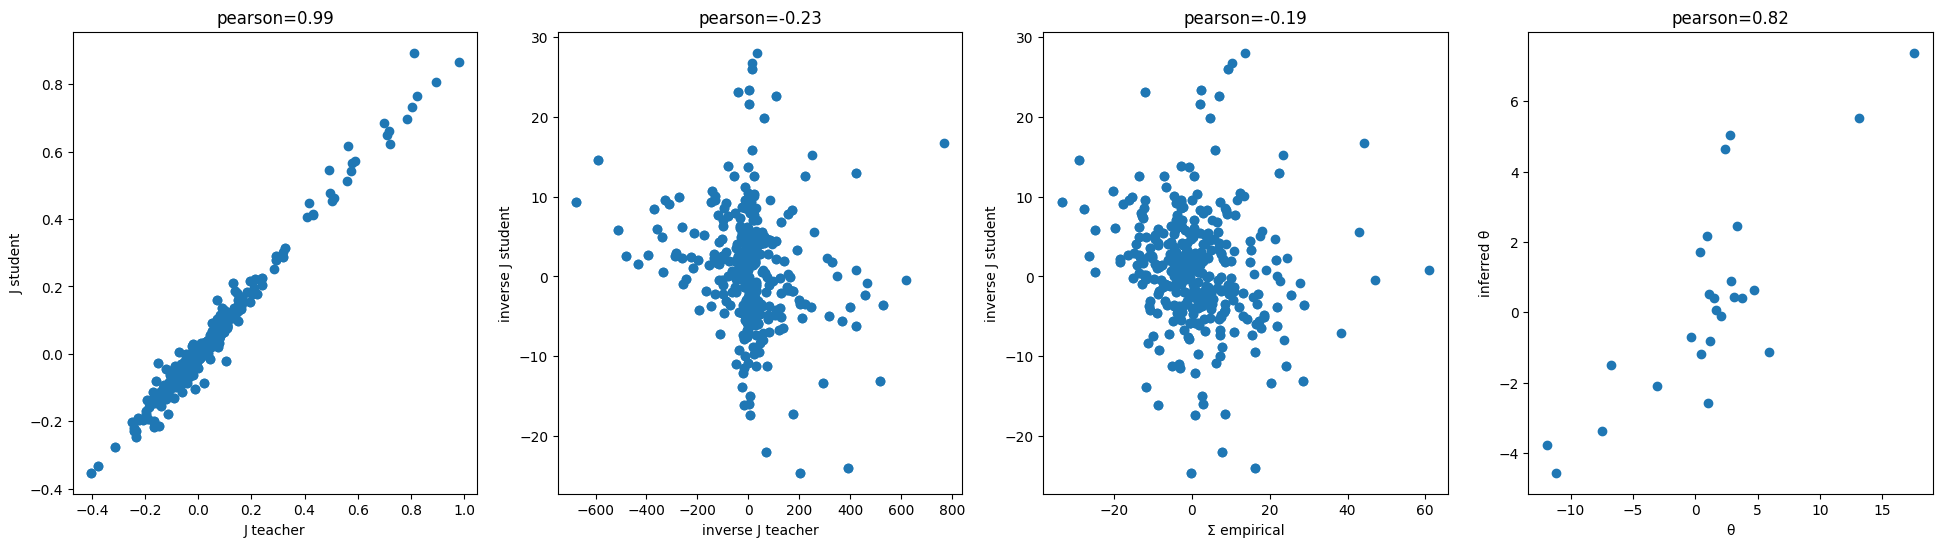

PyObject Text(0.5, 1.0, 'pearson=0.82')

In [27]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, θ_inferred)
rho_theta = cor(vec(θ), θ_inferred)
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")

In [ ]:
γ

In [ ]:
γ_grid = collect(0.01:0.01:0.5)

In [ ]:
lγ = map(x->de.log_likelihood(results.minx[1:end-1], data, x, λ, prior, 0.0), γ_grid)

In [ ]:
plot(γ_grid, lγ .- (minimum(lγ) - 1.0), linestyle="dashed", marker="o", markersize=2)
#xscale(:log)
#yscale(:log)

In [ ]:
#@save "test1_save.jld2" d nsamples T J θ γ x results t_sample γ_grid

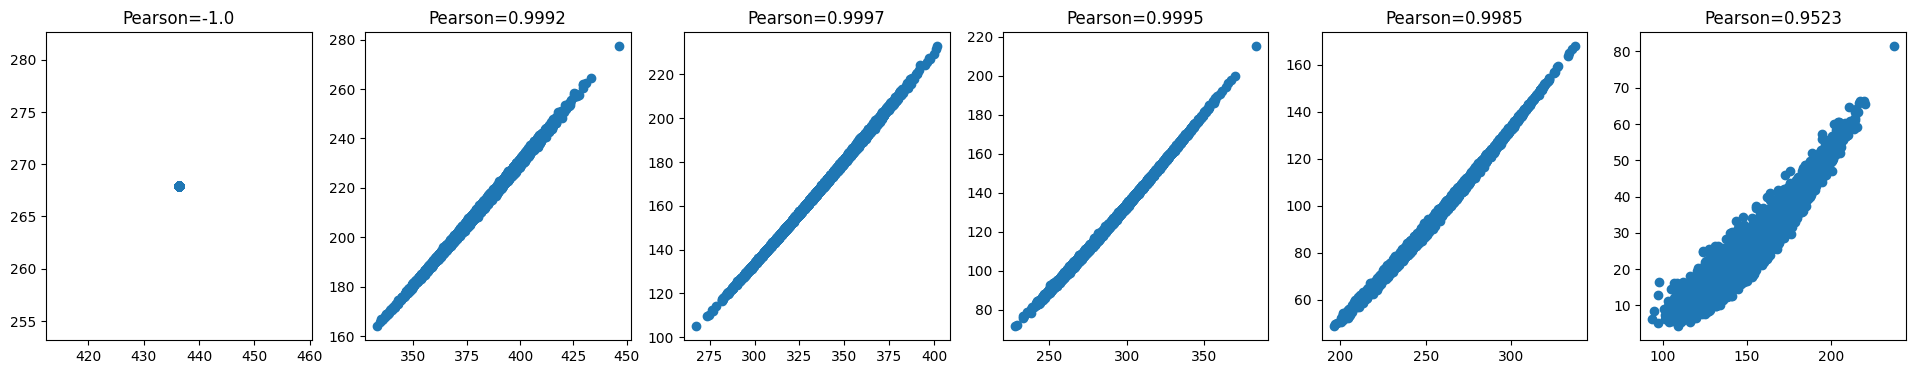

In [53]:
fig, ax = subplots(1, length(t_sample), 4)
for t in eachindex(t_sample)
    teacher_ene = compute_energy(x[:,:, t_sample[t]], J, θ)
    student_ene = compute_energy(x[:,:, t_sample[t]], J_inferred, θ_inferred);
    ax[t].scatter(teacher_ene, student_ene)
    rho = cor(teacher_ene, student_ene)
    ax[t].set_title("Pearson=$(round(rho, digits=4))")
end